In [186]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



In [187]:
df=pd.read_csv("ice_cream_selling_data.csv")

In [188]:
df.head()

,Temperature (C),Ice Cream Sales (units)
0,-4.662263,41.842986
1,-4.316559,34.661120
2,-4.213985,39.383001
3,-3.949661,37.539845
4,-3.578554,32.284531


In [189]:
X=df["Temperature (C)"].values.reshape(-1,1)


In [190]:
y=df["Ice Cream Sales (units)"]

Text(0, 0.5, 'Ice Cream Sales')

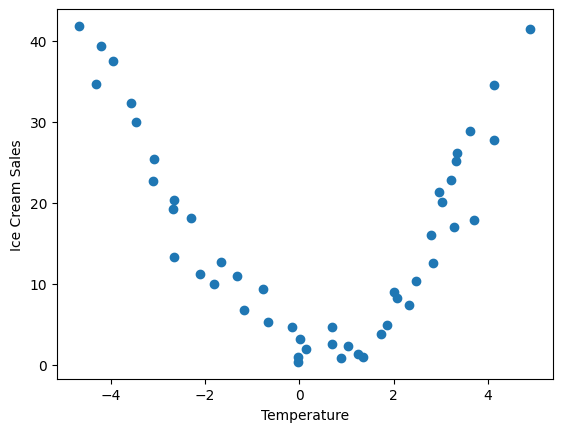

In [191]:
plt.scatter(X,y)
plt.xlabel("Temperature")
plt.ylabel("Ice Cream Sales")

In [192]:
from sklearn.preprocessing import PolynomialFeatures
degree=2
polyfit=PolynomialFeatures(degree=degree)

In [193]:
X_poly=polyfit.fit_transform(X)

In [194]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X_poly,y,test_size=.25,random_state=42)

In [195]:
from sklearn.linear_model import LinearRegression
mod=LinearRegression()
mod.fit(X_train,y_train)

LinearRegression()

In [196]:
y_pred=mod.predict(X_test)

In [197]:
from sklearn.metrics import r2_score,root_mean_squared_error
print(r2_score(y_pred,y_test))
print(root_mean_squared_error(y_pred,y_test))

0.8690011768970198
3.7271829115071666


In [198]:
y_pred1=mod.predict(X_poly)

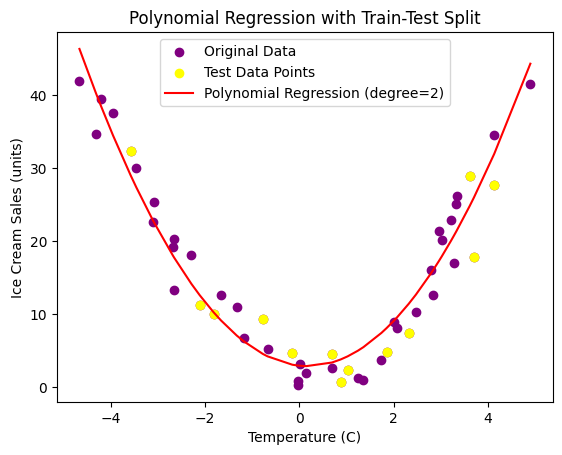

In [199]:
import matplotlib.pyplot as plt

#Generate predictions for the full range of X for plotting the regression line
y_pred_full_range = mod.predict(X_poly)

#Visualize the polynomial regression results
plt.scatter(X, y, color='purple', label='Original Data')
plt.scatter(X_test[:,1], y_test, color='yellow', label='Test Data Points') #Plot test points
plt.plot(X, y_pred_full_range, color='red', label=f'Polynomial Regression (degree={degree})')
plt.xlabel('Temperature (C)')
plt.ylabel('Ice Cream Sales (units)')
plt.title('Polynomial Regression with Train-Test Split')
plt.legend()
plt.show()
